In [160]:
# Install the KaggleHub package if required
!pip -q install kagglehub

In [161]:
# Download the public Big Mart Sales dataset from Kaggle
import kagglehub
import os

dataset_path = kagglehub.dataset_download("ahmadrezagholami2001/bigmart-sales-dataset")

print("Dataset location:")
print(dataset_path)

print("\nAvailable files:")
print(os.listdir(dataset_path))

Using Colab cache for faster access to the 'bigmart-sales-dataset' dataset.
Dataset location:
/kaggle/input/bigmart-sales-dataset

Available files:
['Big Mart Sale Data.csv']


In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Loading


In [163]:
# Find the CSV file available in the downloaded dataset
csv_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(".csv")]
print("CSV files found:", csv_files)

# Select the available Big Mart dataset
if "Big Mart Sale Data.csv" in csv_files:
    file_name = "Big Mart Sale Data.csv"
else:
    file_name = csv_files[0]
file_path = os.path.join(dataset_path, file_name)

# Load the dataset
train = pd.read_csv(file_path)
print("Dataset loaded successfully!")
print("File used:", file_name)
print("Training Rows:", train.shape[0])
print("Training Columns:", train.shape[1])

CSV files found: ['Big Mart Sale Data.csv']
Dataset loaded successfully!
File used: Big Mart Sale Data.csv
Training Rows: 8523
Training Columns: 12


In [164]:
# categorical analysis
categorical_columns = ["Item_Fat_Content", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]
for column in categorical_columns:
    print("\nColumn:", column)
    print("Number of categories:", train[column].nunique(dropna=True))
    print("Categories:", train[column].dropna().unique().tolist())


Column: Item_Fat_Content
Number of categories: 5
Categories: ['Low Fat', 'Regular', 'low fat', 'LF', 'reg']

Column: Outlet_Size
Number of categories: 3
Categories: ['Medium', 'High', 'Small']

Column: Outlet_Location_Type
Number of categories: 3
Categories: ['Tier 1', 'Tier 3', 'Tier 2']

Column: Outlet_Type
Number of categories: 4
Categories: ['Supermarket Type1', 'Supermarket Type2', 'Grocery Store', 'Supermarket Type3']


## Data Understanding


In [165]:
# First five records
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [166]:
# Data types and non-null counts
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [167]:
# Statistical summary of numerical columns
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [168]:
# Number of unique values in each column
unique_summary = pd.DataFrame({
    "Column": train.columns,
    "Unique_Values": [train[col].nunique() for col in train.columns]
})
unique_summary

,Column,Unique_Values
0,Item_Identifier,1559
1,Item_Weight,415
2,Item_Fat_Content,5
3,Item_Visibility,7880
4,Item_Type,16
5,Item_MRP,5938
6,Outlet_Identifier,10
7,Outlet_Establishment_Year,9
8,Outlet_Size,3
9,Outlet_Location_Type,3


## Data Quality Analysis

In [169]:
# Missing values
missing = pd.DataFrame({
    "Missing_Count": train.isnull().sum(),
    "Missing_Percentage": (train.isnull().mean() * 100).round(2)
})
missing.sort_values("Missing_Count", ascending=False)

,Missing_Count,Missing_Percentage
Outlet_Size,2410,28.28
Item_Weight,1463,17.17
Item_Fat_Content,0,0.00
Item_Identifier,0,0.00
Item_Visibility,0,0.00
Item_Type,0,0.00
Outlet_Identifier,0,0.00
Item_MRP,0,0.00
Outlet_Establishment_Year,0,0.00
Outlet_Location_Type,0,0.00


In [170]:
# Duplicate records
print("Duplicate rows:", train.duplicated().sum())

# Check unusual/invalid values
print("Item Visibility equal to zero:", (train["Item_Visibility"] == 0).sum())
print("Item MRP less than or equal to zero:", (train["Item_MRP"] <= 0).sum())
print("Sales less than zero:", (train["Item_Outlet_Sales"] < 0).sum())

Duplicate rows: 0
Item Visibility equal to zero: 526
Item MRP less than or equal to zero: 0
Sales less than zero: 0


## Data Cleaning



In [171]:
df = train.copy()

# Fill missing Item Weight with median
df["Item_Weight"] = df["Item_Weight"].fillna(df["Item_Weight"].median())

# Fill missing Outlet Size with mode
df["Outlet_Size"] = df["Outlet_Size"].fillna(df["Outlet_Size"].mode()[0])

# Standardize inconsistent labels
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "reg": "Regular"
})

# Remove duplicate records
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("\nRemaining missing values:")
print(df.isnull().sum())

Rows before cleaning: 8523
Rows after cleaning: 8523

Remaining missing values:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


## Feature Engineering



In [172]:
# Create outlet age
reference_year = df["Outlet_Establishment_Year"].max()
df["Outlet_Age"] = reference_year - df["Outlet_Establishment_Year"]

# Create MRP bands
df["Item_MRP_Band"] = pd.cut(
    df["Item_MRP"],
    bins=[-np.inf, 70, 140, 210, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# Create visibility levels using dataset quantiles
q1 = df["Item_Visibility"].quantile(0.33)
q2 = df["Item_Visibility"].quantile(0.66)

df["Visibility_Level"] = pd.cut(
    df["Item_Visibility"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)
result = df[
    [
        "Outlet_Establishment_Year",
        "Outlet_Age",
        "Item_MRP",
        "Item_MRP_Band",
        "Item_Visibility",
        "Visibility_Level"
    ]
].head()
display(result)

,Outlet_Establishment_Year,Outlet_Age,Item_MRP,Item_MRP_Band,Item_Visibility,Visibility_Level
0,1999,10,249.8092,Very High,0.016047,Low
1,2009,0,48.2692,Low,0.019278,Low
2,1999,10,141.6180,High,0.016760,Low
3,1998,11,182.0950,High,0.000000,Low
4,1987,22,53.8614,Low,0.000000,Low


## Exploratory Data Analysis


In [173]:
# Overall sales statistics
sales_stats = df["Item_Outlet_Sales"].agg(["count", "mean", "median", "std", "min", "max"])
sales_stats

,Item_Outlet_Sales
count,8523.000000
mean,2181.288914
median,1794.331000
std,1706.499616
min,33.290000
max,13086.964800


In [174]:
# Average sales by outlet type
outlet_type_sales = (
    df.groupby("Outlet_Type", observed=True)["Item_Outlet_Sales"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)
outlet_type_sales

,mean,median,count
Outlet_Type,,,
Supermarket Type3,3694.038558,3364.9532,935
Supermarket Type1,2316.181148,1990.7420,5577
Supermarket Type2,1995.498739,1655.1788,928
Grocery Store,339.828500,256.9988,1083


In [175]:
# Average sales by location type
location_sales = (
    df.groupby("Outlet_Location_Type", observed=True)["Item_Outlet_Sales"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)
location_sales

,mean,median,count
Outlet_Location_Type,,,
Tier 2,2323.990559,2004.0580,2785
Tier 3,2279.627651,1812.3076,3350
Tier 1,1876.909159,1487.3972,2388


In [176]:
# Average sales by item type
item_type_sales = (
    df.groupby("Item_Type", observed=True)["Item_Outlet_Sales"]
      .mean()
      .sort_values(ascending=False)
)
item_type_sales

,Item_Outlet_Sales
Item_Type,
Starchy Foods,2374.332773
Seafood,2326.065928
Fruits and Vegetables,2289.009592
Snack Foods,2277.321739
Household,2258.784300
Dairy,2232.542597
Canned,2225.194904
Breads,2204.132226
Meat,2158.977911


In [177]:
# Sales by fat content
fat_sales = (
    df.groupby("Item_Fat_Content", observed=True)["Item_Outlet_Sales"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)
fat_sales

,mean,median,count
Item_Fat_Content,,,
Regular,2224.561170,1844.5989,3006
Low Fat,2159.161438,1768.3648,5405
low fat,2087.740737,1614.2321,112


In [178]:
# Average sales by outlet identifier
store_sales = (
    df.groupby("Outlet_Identifier")["Item_Outlet_Sales"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)
store_sales

,mean,median,count
Outlet_Identifier,,,
OUT027,3694.038558,3364.9532,935
OUT035,2438.841866,2109.2544,930
OUT049,2348.354635,1966.1074,930
OUT017,2340.675263,2005.0567,926
OUT013,2298.995256,2050.6640,932
OUT046,2277.844267,1945.8005,930
OUT045,2192.384798,1834.9448,929
OUT018,1995.498739,1655.1788,928
OUT019,340.329723,265.3213,528


## Correlation and Relationship Analysis


In [179]:
numeric_cols = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Outlet_Age",
    "Item_Outlet_Sales"
]
correlation = df[numeric_cols].corr()
correlation.round(3)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Age,Item_Outlet_Sales
Item_Weight,1.000,-0.014,0.025,0.008,-0.008,0.010
Item_Visibility,-0.014,1.000,-0.001,-0.075,0.075,-0.129
Item_MRP,0.025,-0.001,1.000,0.005,-0.005,0.568
Outlet_Establishment_Year,0.008,-0.075,0.005,1.000,-1.000,-0.049
Outlet_Age,-0.008,0.075,-0.005,-1.000,1.000,0.049
Item_Outlet_Sales,0.010,-0.129,0.568,-0.049,0.049,1.000


## Data Visualization



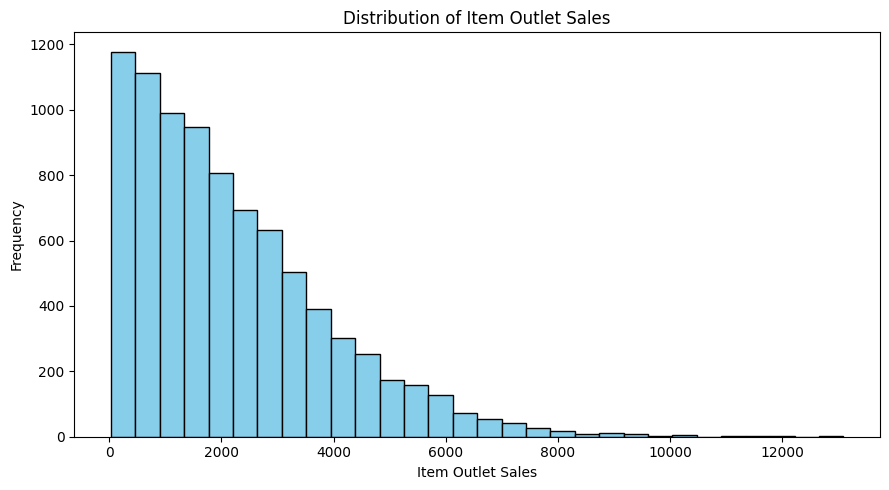

In [180]:
# 1. Sales distribution
plt.figure(figsize=(9, 5))

plt.hist(df["Item_Outlet_Sales"], bins=30, color="skyblue", edgecolor="black")

plt.xlabel("Item Outlet Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Item Outlet Sales")

plt.tight_layout()
plt.show()

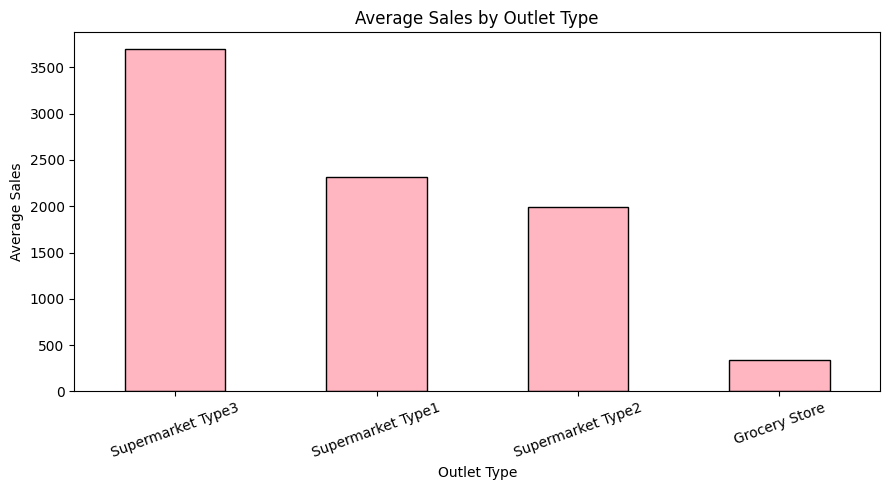

In [181]:
# 2. Average sales by outlet type
plt.figure(figsize=(9, 5))
outlet_type_sales["mean"].plot(
    kind="bar",
    color="lightpink",
    edgecolor="black"
)
plt.xlabel("Outlet Type")
plt.ylabel("Average Sales")
plt.title("Average Sales by Outlet Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

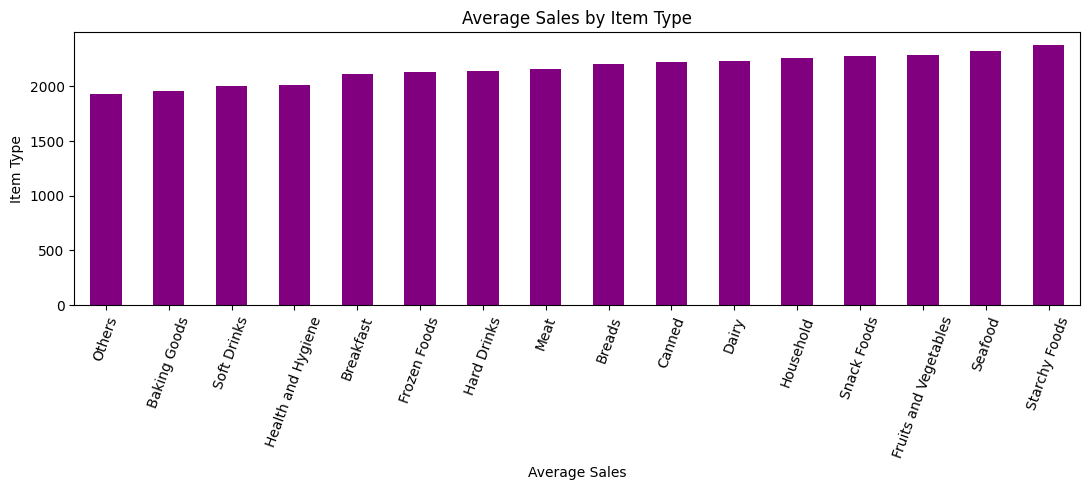

In [182]:
# 3. Average sales by item type
plt.figure(figsize=(11, 5))
item_type_sales.sort_values().plot(
    kind="bar",
    color="purple",
)
plt.xlabel("Average Sales")
plt.ylabel("Item Type")
plt.title("Average Sales by Item Type")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

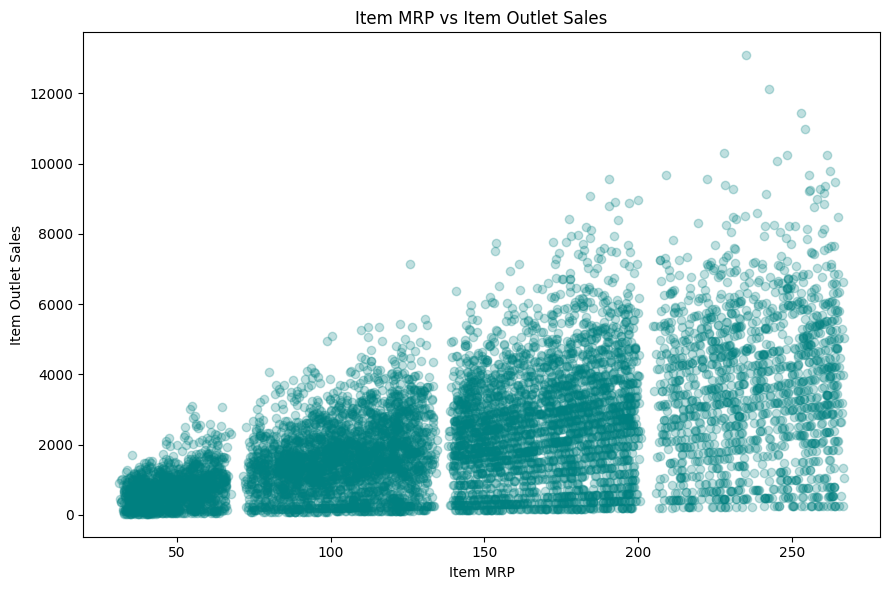

In [183]:
# 4. MRP versus sales
plt.figure(figsize=(9, 6))
plt.scatter(
    df["Item_MRP"],
    df["Item_Outlet_Sales"],
    alpha=0.25,
    color="teal"
)
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.title("Item MRP vs Item Outlet Sales")
plt.tight_layout()
plt.show()

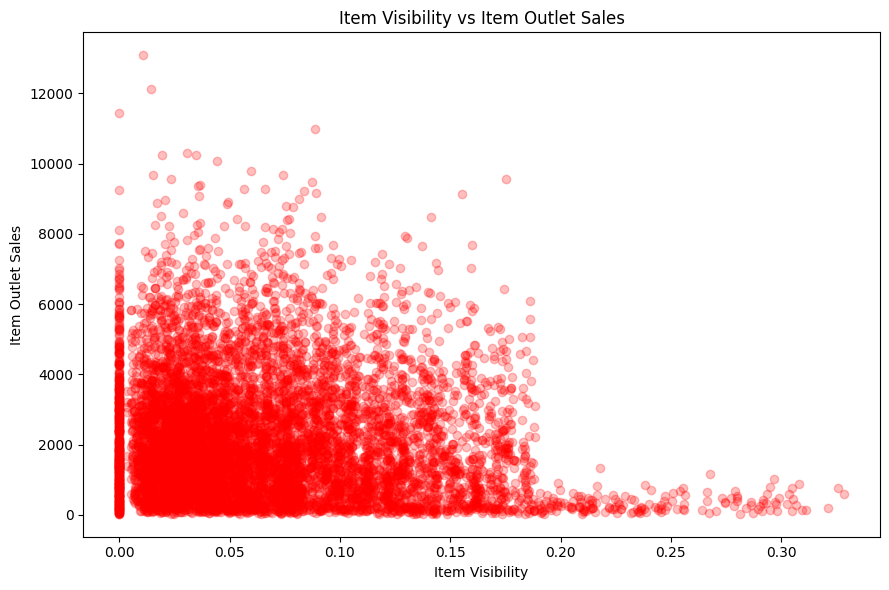

In [184]:
# 5. Visibility versus sales
plt.figure(figsize=(9, 6))
plt.scatter(
    df["Item_Visibility"],
    df["Item_Outlet_Sales"],
    alpha=0.25,
    color="red"
)
plt.xlabel("Item Visibility")
plt.ylabel("Item Outlet Sales")
plt.title("Item Visibility vs Item Outlet Sales")
plt.tight_layout()
plt.show()

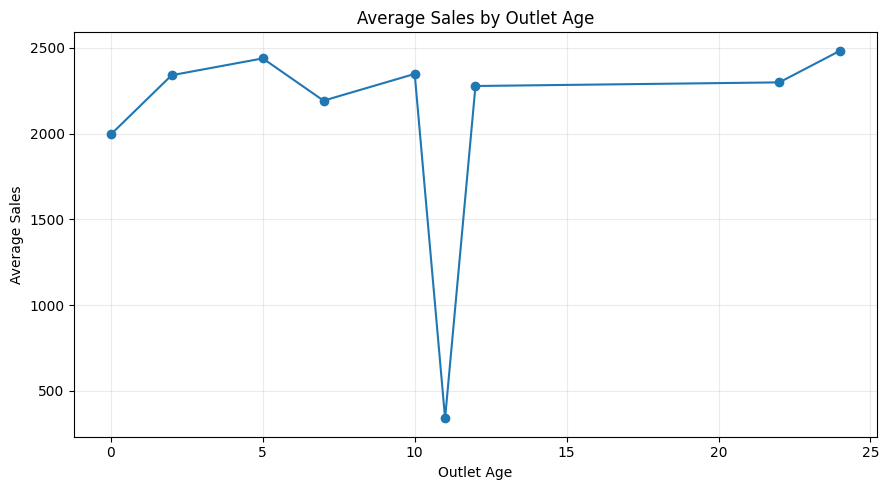

In [185]:
# 6. Outlet age versus average sales
age_sales = df.groupby("Outlet_Age")["Item_Outlet_Sales"].mean().sort_index()
plt.figure(figsize=(9, 5))
plt.plot(age_sales.index, age_sales.values, marker="o")
plt.xlabel("Outlet Age")
plt.ylabel("Average Sales")
plt.title("Average Sales by Outlet Age")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Preparing Data for Linear Regression



In [186]:
# Predictor variables
features = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Outlet_Age",
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Identifier",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type",
    "Item_MRP_Band",
    "Visibility_Level"
]
X = df[features]
y = df["Item_Outlet_Sales"]
categorical_features = [
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Identifier",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type",
    "Item_MRP_Band",
    "Visibility_Level"
]
numeric_features = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Outlet_Age"
]
print("Total predictor columns before encoding:", X.shape[1])

Total predictor columns before encoding: 13


In [187]:
# Preprocessing for categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)
# Linear Regression model
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 6818
Testing records: 1705


## Model Building – Linear Regression


In [188]:
# Train the Linear Regression model
linear_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Sales Prediction




In [189]:
# Predict sales
y_pred = linear_model.predict(X_test)
prediction_table = pd.DataFrame({
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})
prediction_table.head(10)

,Actual_Sales,Predicted_Sales
0,1743.0644,1368.375977
1,356.8688,667.604463
2,377.5086,828.682847
3,5778.4782,4215.858416
4,2356.9320,3403.113931
5,865.5400,583.488941
6,4613.9940,4801.949365
7,2410.8618,2076.741317
8,1948.1308,1414.554911
9,1937.4780,2839.369177


## Model Evaluation



In [190]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Model Evaluation")
print("----------------")
print("R² Score :", round(r2, 4))
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))

Model Evaluation
----------------
R² Score : 0.5779
MAE      : 793.65
RMSE     : 1071.06


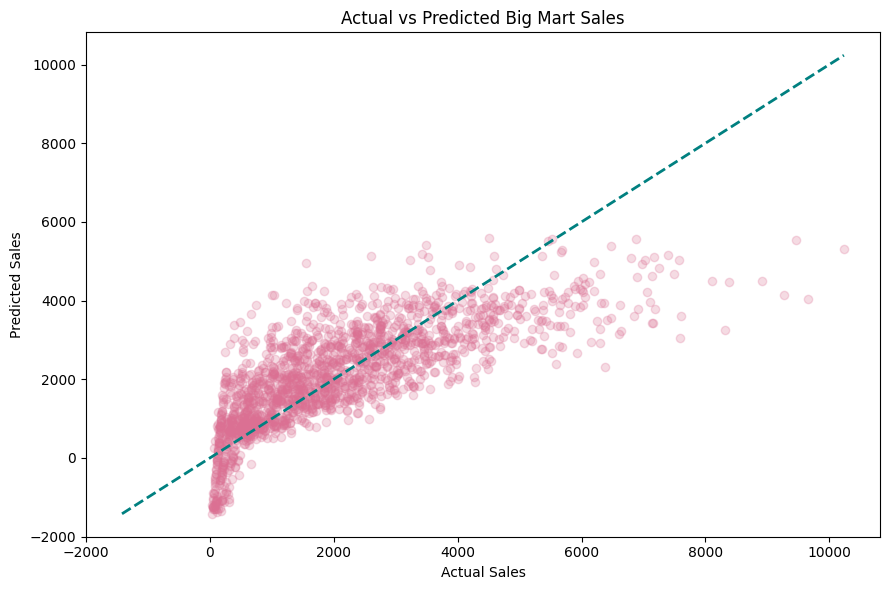

In [191]:
plt.figure(figsize=(9, 6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.25,
    color="palevioletred"
)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="teal",
    linestyle="--",
    linewidth=2
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Big Mart Sales")
plt.tight_layout()
plt.show()

## Prediction Error Analysis



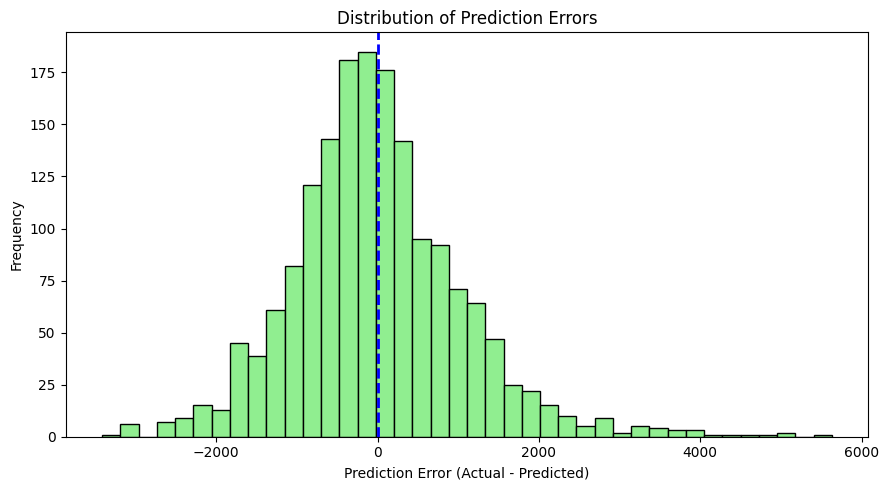

In [192]:
residuals = y_test.values - y_pred
plt.figure(figsize=(9, 5))
plt.hist(
    residuals,
    bins=40,
    color="lightgreen",
    edgecolor="black"
)
plt.axvline(
    0,
    color="blue",
    linestyle="--",
    linewidth=2
)
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.tight_layout()
plt.show()

## Business-Oriented Insights


In [193]:
# Automatically display a few key findings from the analysis
highest_outlet_type = outlet_type_sales["mean"].idxmax()
highest_item_type = item_type_sales.idxmax()
highest_store = store_sales["mean"].idxmax()
print("Key Findings")
print("------------")
print("Highest average-sales outlet type:", highest_outlet_type)
print("Highest average-sales item category:", highest_item_type)
print("Highest average-sales outlet:", highest_store)
print("R² Score of Linear Regression:", round(r2, 4))

Key Findings
------------
Highest average-sales outlet type: Supermarket Type3
Highest average-sales item category: Starchy Foods
Highest average-sales outlet: OUT027
R² Score of Linear Regression: 0.5779
